In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

from PIL import Image
import rasterio

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

CUDA available: True
Using device: cuda


In [6]:
# paths
RGB_TRAIN = "EuroSAT/train"
RGB_VAL   = "EuroSAT/val"
MS_TRAIN  = "EuroSATallBands/train"
MS_VAL    = "EuroSATallBands/val"
RGB_TEST  = "EuroSAT_test_flat"
MS_TEST   = "EuroSATallBands_test_flat"

CLASSES = [
    "AnnualCrop", "Forest", "HerbaceousVegetation", "Highway",
    "Industrial", "Pasture", "PermanentCrop", "Residential",
    "River", "SeaLake"
]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
NUM_CLASSES  = 10

# training
BATCH_SIZE = 64
EPOCHS     = 50
LR         = 1e-3
PATIENCE   = 7   # early stopping patience

In [7]:
rgb_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class RGBDataset(Dataset):
    def __init__(self, root, transform=None):
        self.samples = []
        self.transform = transform
        for cls in CLASSES:
            folder = os.path.join(root, cls)
            for fname in os.listdir(folder):
                if fname.lower().endswith(".jpg"):
                    self.samples.append((os.path.join(folder, fname), CLASS_TO_IDX[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

# quick sanity check
rgb_train_ds = RGBDataset(RGB_TRAIN, rgb_transforms)
rgb_val_ds   = RGBDataset(RGB_VAL,   rgb_transforms)
print("RGB train:", len(rgb_train_ds), "| val:", len(rgb_val_ds))
img, lbl = rgb_train_ds[0]
print("Image shape:", img.shape, "| label:", lbl)

RGB train: 18900 | val: 4050
Image shape: torch.Size([3, 64, 64]) | label: 0


In [8]:
class MSDataset(Dataset):
    def __init__(self, root):
        self.samples = []
        for cls in CLASSES:
            folder = os.path.join(root, cls)
            for fname in os.listdir(folder):
                if fname.lower().endswith(".tif"):
                    self.samples.append((os.path.join(folder, fname), CLASS_TO_IDX[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        with rasterio.open(path) as src:
            img = src.read().astype(np.float32)  # shape: (13, 64, 64)
        img = img / 10000.0                       # normalize to 0-1
        img = np.clip(img, 0, 1)
        return torch.tensor(img), label

ms_train_ds = MSDataset(MS_TRAIN)
ms_val_ds   = MSDataset(MS_VAL)
print("MS train:", len(ms_train_ds), "| val:", len(ms_val_ds))
img, lbl = ms_train_ds[0]
print("MS image shape:", img.shape, "| min:", img.min().item(), "| max:", img.max().item())
# if max is way above 1 after /10000, the raw data might already be normalized, let us know

MS train: 18900 | val: 4050
MS image shape: torch.Size([13, 64, 64]) | min: 0.0008999999845400453 | max: 0.3490000069141388


In [9]:
rgb_train_loader = DataLoader(rgb_train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
rgb_val_loader   = DataLoader(rgb_val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
ms_train_loader  = DataLoader(ms_train_ds,  batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
ms_val_loader    = DataLoader(ms_val_ds,    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

In [10]:
class BaseCNN(nn.Module):
    def __init__(self, in_channels, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),  # 32x32
            nn.Conv2d(32, 64, 3, padding=1),          nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),  # 16x16
            nn.Conv2d(64, 128, 3, padding=1),         nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2), # 8x8
            nn.Conv2d(128, 256, 3, padding=1),        nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2), # 4x4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

# test forward pass
model_test = BaseCNN(in_channels=3).to(device)
dummy = torch.randn(2, 3, 64, 64).to(device)
print("RGB CNN output shape:", model_test(dummy).shape)

model_test2 = BaseCNN(in_channels=13).to(device)
dummy2 = torch.randn(2, 13, 64, 64).to(device)
print("MS CNN output shape:", model_test2(dummy2).shape)

RGB CNN output shape: torch.Size([2, 10])
MS CNN output shape: torch.Size([2, 10])


In [18]:
class EarlyStopping:
    def __init__(self, patience=7, save_path="best_model.pt"):
        self.patience  = patience
        self.best_loss = float("inf")
        self.counter   = 0
        self.save_path = save_path

    def step(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), self.save_path)
            return False  # don't stop
        self.counter += 1
        return self.counter >= self.patience  # stop if True


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct    += (out.argmax(1) == y).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out  = model(x)
            loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            correct    += (out.argmax(1) == y).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n


def run_training(model, train_loader, val_loader, save_path, 
                 epochs=EPOCHS, lr=LR, patience=PATIENCE, grad_clip=None):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    criterion = nn.CrossEntropyLoss()
    stopper   = EarlyStopping(patience=patience, save_path=save_path)
    history   = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, correct = 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out  = model(x)
            loss = criterion(out, y)
            loss.backward()
            if grad_clip:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct    += (out.argmax(1) == y).sum().item()
        n  = len(train_loader.dataset)
        tl, ta = total_loss / n, correct / n

        vl, va = evaluate(model, val_loader, criterion)
        scheduler.step(vl)
        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        history["train_acc"].append(ta)
        history["val_acc"].append(va)
        print(f"Epoch {epoch:02d} | train_loss={tl:.4f} acc={ta:.3f} | val_loss={vl:.4f} acc={va:.3f}")
        if stopper.step(vl, model):
            print(f"Early stopping at epoch {epoch}. Best val_loss={stopper.best_loss:.4f}")
            break

    model.load_state_dict(torch.load(save_path))
    return history

In [ ]:
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history["train_loss"], label="train")
    ax1.plot(history["val_loss"],   label="val")
    ax1.set_title(f"{title} - Loss"); ax1.legend()
    ax2.plot(history["train_acc"], label="train")
    ax2.plot(history["val_acc"],   label="val")
    ax2.set_title(f"{title} - Accuracy"); ax2.legend()
    plt.tight_layout(); plt.show()

In [ ]:
cnn_rgb = BaseCNN(in_channels=3).to(device)
history_cnn_rgb = run_training(cnn_rgb, rgb_train_loader, rgb_val_loader, save_path="cnn_rgb_best.pt", lr=1e-3, patience=7, grad_clip=None)

Epoch 01 | train_loss=1.0128 acc=0.646 | val_loss=0.7775 acc=0.718
Epoch 02 | train_loss=0.6842 acc=0.762 | val_loss=0.7006 acc=0.748
Epoch 03 | train_loss=0.5961 acc=0.795 | val_loss=0.4884 acc=0.836
Epoch 04 | train_loss=0.5226 acc=0.822 | val_loss=0.5487 acc=0.823
Epoch 05 | train_loss=0.4570 acc=0.843 | val_loss=0.4464 acc=0.856
Epoch 06 | train_loss=0.4194 acc=0.857 | val_loss=0.3877 acc=0.857
Epoch 07 | train_loss=0.3839 acc=0.866 | val_loss=0.4154 acc=0.865
Epoch 08 | train_loss=0.3341 acc=0.886 | val_loss=0.7547 acc=0.793
Epoch 09 | train_loss=0.3002 acc=0.899 | val_loss=0.5419 acc=0.843
Epoch 10 | train_loss=0.2850 acc=0.901 | val_loss=0.2530 acc=0.915
Epoch 11 | train_loss=0.2578 acc=0.910 | val_loss=0.3097 acc=0.899
Epoch 12 | train_loss=0.2502 acc=0.915 | val_loss=0.2626 acc=0.908
Epoch 13 | train_loss=0.2237 acc=0.923 | val_loss=0.3117 acc=0.903
Epoch 14 | train_loss=0.2077 acc=0.927 | val_loss=0.4268 acc=0.878
Epoch 15 | train_loss=0.1425 acc=0.948 | val_loss=0.2266 acc=0

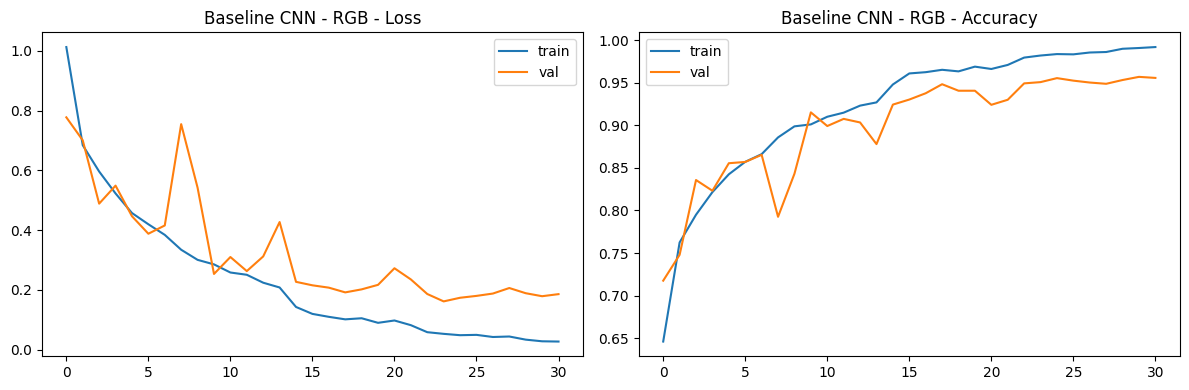

In [16]:
plot_history(history_cnn_rgb, "Baseline CNN - RGB")

In [21]:
cnn_ms = BaseCNN(in_channels=13).to(device)

# history_cnn_ms = run_training(cnn_ms, ms_train_loader, ms_val_loader, save_path="cnn_ms_best.pt")
history_cnn_ms = run_training(
    cnn_ms, ms_train_loader, ms_val_loader,
    save_path="cnn_ms_best.pt",
    lr=3e-4,       # lower than default 1e-3
    patience=5,   # more forgiving given the swings
    grad_clip=1.0  # clips exploding gradients
)

Epoch 01 | train_loss=0.5309 acc=0.818 | val_loss=1.3464 acc=0.685
Epoch 02 | train_loss=0.3051 acc=0.897 | val_loss=0.2429 acc=0.918
Epoch 03 | train_loss=0.2547 acc=0.917 | val_loss=0.3608 acc=0.883
Epoch 04 | train_loss=0.2042 acc=0.932 | val_loss=0.4947 acc=0.847
Epoch 05 | train_loss=0.1811 acc=0.939 | val_loss=0.2923 acc=0.907
Epoch 06 | train_loss=0.1674 acc=0.944 | val_loss=0.3178 acc=0.891
Epoch 07 | train_loss=0.1044 acc=0.965 | val_loss=0.3052 acc=0.905
Early stopping at epoch 7. Best val_loss=0.2429


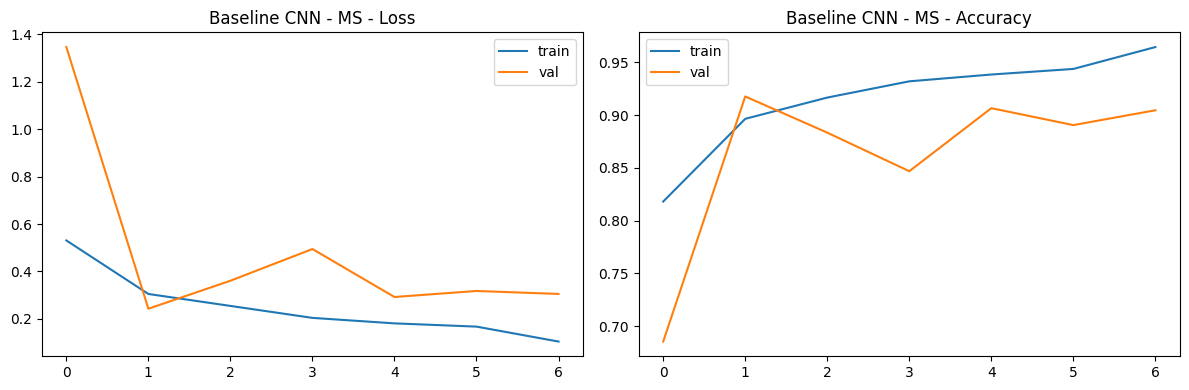

In [22]:
plot_history(history_cnn_ms,  "Baseline CNN - MS")